# Computer Vision Lab: CNN for Fashion MNIST


- Load and explore image datasets
- Apply data augmentation (rotations)
- Build a simple CNN architecture
- Train and evaluate the model

## Part 1: Setup and Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image


## Task 1: Load and Explore Fashion MNIST Dataset

In [2]:
# Task 1.1: Load Fashion MNIST and print dataset info

# Load the dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to [0, 1]
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# Further normalize (zero-center)
mean = 0.1307
std = 0.3081
x_train_final = (x_train_normalized - mean) / std
x_test_final = (x_test_normalized - mean) / std

# Print dataset information
print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")
print(f"Image shape: {x_train.shape[1:]}")
print(f"Number of classes: 10")
print(f"\nData types:")
print(f"  x_train: {x_train.dtype}, shape: {x_train.shape}")
print(f"  y_train: {y_train.dtype}, shape: {y_train.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples: 10000
Image shape: (28, 28)
Number of classes: 10

Data types:
  x_train: uint8, shape: (60000, 28, 28)
  y_train: uint8, shape: (60000,)


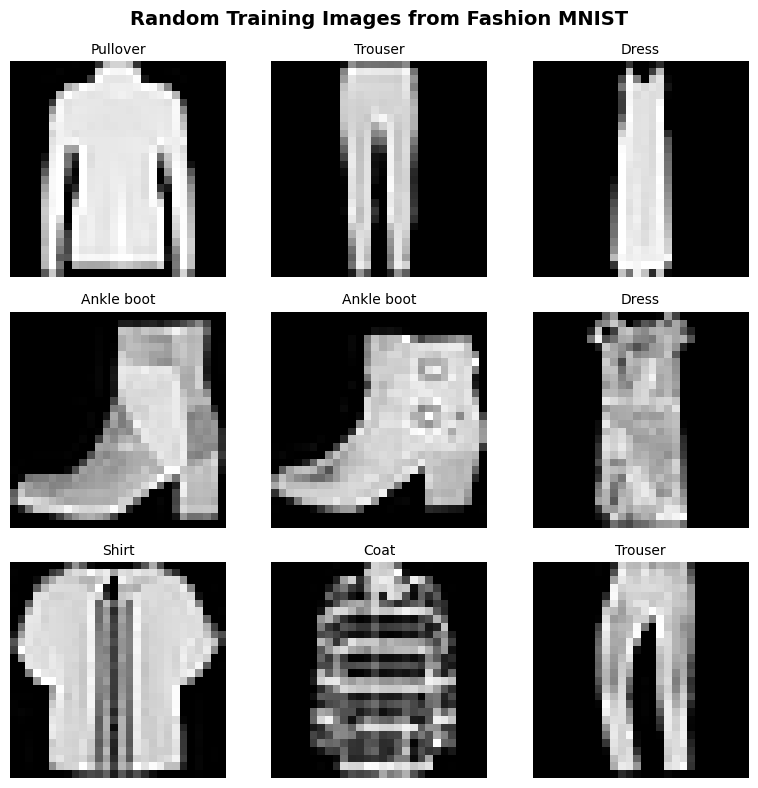

In [3]:
# Task 1.2: Display a 3x3 grid of random training images with labels

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Create a figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('Random Training Images from Fashion MNIST', fontsize=14, fontweight='bold')

# Get 9 random indices
indices = np.random.choice(len(x_train), 9, replace=False)

for idx, ax in enumerate(axes.flat):
    image_data = x_train[indices[idx]]
    ax.imshow(image_data, cmap='gray')
    ax.set_title(class_names[y_train[indices[idx]]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Task 1.3: Print pixel value statistics before and after normalization

print("=== Before Normalization (Raw pixels) ===")
print(f"Min: {x_train.min()}")
print(f"Max: {x_train.max()}")
print(f"Mean: {x_train.mean():.4f}")
print(f"Std: {x_train.std():.4f}")

print("\n=== After ToTensor [0-1] ===")
print(f"Min: {x_train_normalized.min():.4f}")
print(f"Max: {x_train_normalized.max():.4f}")
print(f"Mean: {x_train_normalized.mean():.4f}")
print(f"Std: {x_train_normalized.std():.4f}")

print("\n=== After Normalize(mean=0.1307, std=0.3081) ===")
print(f"Min: {x_train_final.min():.4f}")
print(f"Max: {x_train_final.max():.4f}")
print(f"Mean: {x_train_final.mean():.4f}")
print(f"Std: {x_train_final.std():.4f}")

=== Before Normalization (Raw pixels) ===
Min: 0
Max: 255
Mean: 72.9404
Std: 90.0212

=== After ToTensor [0-1] ===
Min: 0.0000
Max: 1.0000
Mean: 0.2860
Std: 0.3530

=== After Normalize(mean=0.1307, std=0.3081) ===
Min: -0.4242
Max: 2.8215
Mean: 0.5042
Std: 1.1458


## Task 2: Data Augmentation

In [5]:
# Task 2.1: Build data augmentation pipelines

# Augmentation for training (random rotation 0-30 degrees)
def apply_augmentation(x, y, rotation_range=30):
    """
    Apply data augmentation: random rotation
    x: images (28, 28) in grayscale
    Returns: augmented images
    """
    # Add batch dimension if needed
    if len(x.shape) == 2:
        x = np.expand_dims(x, axis=0)

    # Random rotation angle
    angle = np.random.uniform(-rotation_range, rotation_range)

    # Apply rotation
    x_augmented = image.random_rotation(x, rg=rotation_range, row_axis=0, col_axis=1, channel_axis=2)

    return x_augmented.squeeze(), y

# Create augmented training dataset
def create_augmented_dataset(x, y, batch_size=32, rotation_range=30):
    """
    Create a TensorFlow dataset with augmentation.
    """
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    return dataset

# Create non-augmented dataset
def create_dataset(x, y, batch_size=32, shuffle=True):
    """
    Create a simple TensorFlow dataset (no augmentation).
    """
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    return dataset

print("✓ Augmentation pipelines created")

✓ Augmentation pipelines created


In [6]:
# Task 2.2: Implement RandomRotationMultiple90 function

def rotate_by_multiple_90(image, k):
    """
    Rotate image by k*90 degrees.
    k: 0, 1, 2, or 3 (corresponds to 0°, 90°, 180°, 270°)
    """
    return np.rot90(image, k)

# Test the function
test_img = x_train[0]
print("Testing RandomRotationMultiple90:")
for k in range(4):
    rotated = rotate_by_multiple_90(test_img, k)
    print(f"  k={k}: {k*90}° rotation, shape: {rotated.shape}")

print("✓ RandomRotationMultiple90 works correctly (0°, 90°, 180°, 270°)")

Testing RandomRotationMultiple90:
  k=0: 0° rotation, shape: (28, 28)
  k=1: 90° rotation, shape: (28, 28)
  k=2: 180° rotation, shape: (28, 28)
  k=3: 270° rotation, shape: (28, 28)
✓ RandomRotationMultiple90 works correctly (0°, 90°, 180°, 270°)


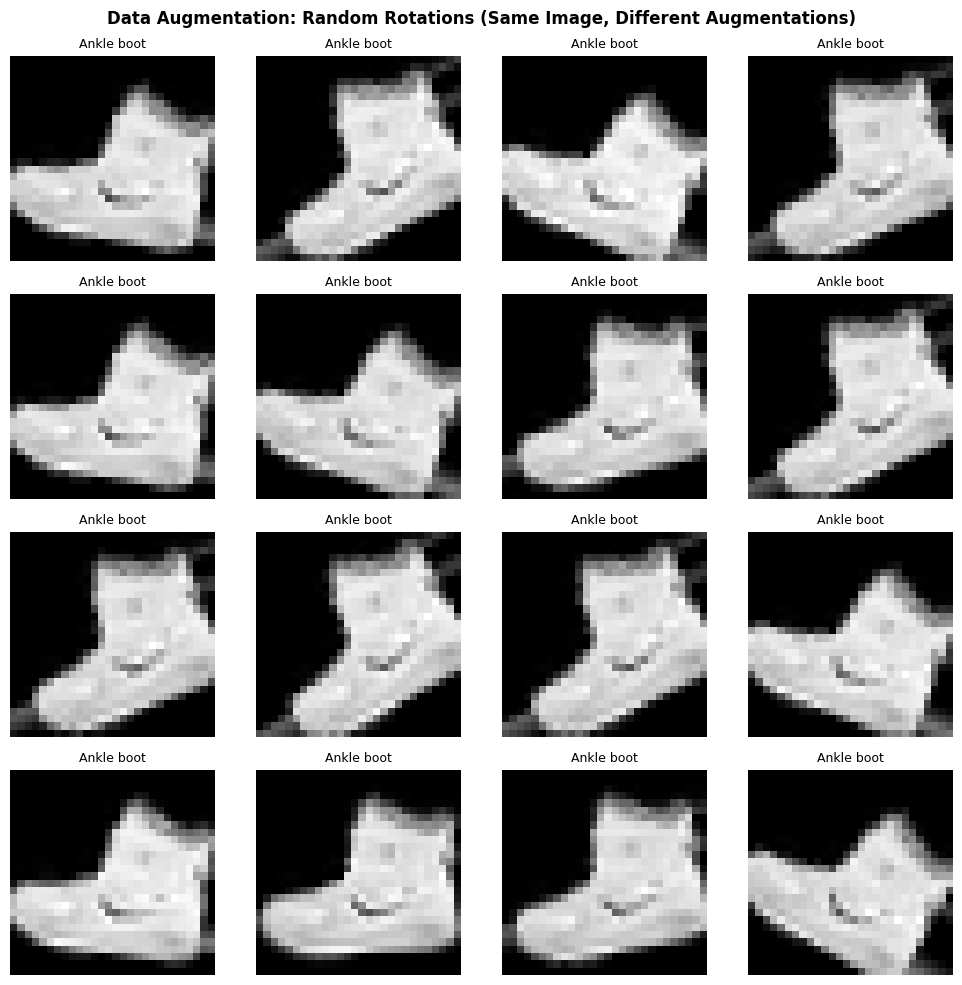

In [7]:
# Task 2.3: Visualize a 4x4 grid of augmented samples

# Create data augmentation generator
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=30,
    fill_mode='nearest'
)

# Create a figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Data Augmentation: Random Rotations (Same Image, Different Augmentations)',
             fontsize=12, fontweight='bold')

# Show the same image 16 times with different augmentations
sample_idx = 0
sample_image = x_train[sample_idx]
sample_label = y_train[sample_idx]

# Reshape for data generator (needs 4D array)
sample_reshaped = np.expand_dims(np.expand_dims(sample_image, axis=0), axis=-1)

# Generate augmented images
aug_iterator = datagen.flow(sample_reshaped, batch_size=1)

for ax in axes.flat:
    aug_batch = next(aug_iterator)
    aug_image = aug_batch[0].squeeze()
    ax.imshow(aug_image, cmap='gray')
    ax.set_title(class_names[sample_label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Task 2.4: Compare pixel statistics with Rotation(0) vs Rotation(180)

# Get a batch of images
sample_batch_0 = x_train[:32].copy()
sample_batch_180 = np.array([np.rot90(img, 2) for img in x_train[:32]])

print("=== Rotation 0° ===")
print(f"Mean: {sample_batch_0.mean():.4f}")
print(f"Std: {sample_batch_0.std():.4f}")
print(f"Min: {sample_batch_0.min():.4f}")
print(f"Max: {sample_batch_0.max():.4f}")

print("\n=== Rotation 180° ===")
print(f"Mean: {sample_batch_180.mean():.4f}")
print(f"Std: {sample_batch_180.std():.4f}")
print(f"Min: {sample_batch_180.min():.4f}")
print(f"Max: {sample_batch_180.max():.4f}")

print("\n(Note: Statistics should be very similar since rotation doesn't change pixel values)")

=== Rotation 0° ===
Mean: 76.3058
Std: 91.0322
Min: 0.0000
Max: 255.0000

=== Rotation 180° ===
Mean: 76.3058
Std: 91.0322
Min: 0.0000
Max: 255.0000

(Note: Statistics should be very similar since rotation doesn't change pixel values)


## Task 3: CNN Architecture (Simple Sequential Model)

In [9]:
# Task 3.1 & 3.2: Build CNN model using Sequential API (no OOP)

def build_cnn_model():
    """
    Build a simple CNN with 3 blocks.
    Each block: Conv2D -> BatchNorm -> ReLU -> MaxPool
    """
    model = keras.Sequential([
        # Input layer (will be (28, 28, 1))
        layers.Input(shape=(28, 28, 1)),

        # Block 1: 32 filters
        layers.Conv2D(32, kernel_size=3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=2),  # (28, 28) -> (14, 14)

        # Block 2: 64 filters
        layers.Conv2D(64, kernel_size=3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=2),  # (14, 14) -> (7, 7)

        # Block 3: 128 filters
        layers.Conv2D(128, kernel_size=3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=2),  # (7, 7) -> (3, 3)

        # Flatten
        layers.Flatten(),  # (128, 3, 3) -> (128*9)

        # Classifier head
        layers.Dense(256),
        layers.ReLU(),
        layers.Dropout(0.4),
        layers.Dense(10)  # 10 classes
    ])

    return model

# Create model
cnn_model = build_cnn_model()

# Print model summary
print("Model created successfully!")
cnn_model.summary()

Model created successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

## Task 4: Training and Evaluation

In [11]:
# Setup training datasets

batch_size = 64

# Expand dimensions for TensorFlow (add channel dimension)
x_train_expanded = np.expand_dims(x_train_final, axis=-1)
x_test_expanded = np.expand_dims(x_test_final, axis=-1)

# Create datasets
train_dataset_aug = create_augmented_dataset(x_train_expanded, y_train, batch_size=batch_size)
train_dataset_no_aug = create_dataset(x_train_expanded, y_train, batch_size=batch_size, shuffle=True)
val_dataset = create_dataset(x_test_expanded, y_test, batch_size=batch_size, shuffle=False)

print(f"Train dataset (with augmentation): created")
print(f"Train dataset (no augmentation): created")
print(f"Val dataset: created")
print(f"Batch size: {batch_size}")

Train dataset (with augmentation): created
Train dataset (no augmentation): created
Val dataset: created
Batch size: 64


In [12]:
# Task 4.1: Train CNN with augmentation for 20 epochs

print("Building model with augmentation...\n")

# Create fresh model
model_with_aug = build_cnn_model()

# Compile model
model_with_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Train with augmentation
print("Training with augmentation...\n")


history_aug = model_with_aug.fit(
    train_dataset_aug,
    validation_data=val_dataset,
    epochs=20,
    verbose=1,

)

print("\nTraining completed!")

Building model with augmentation...

Training with augmentation...

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8306 - loss: 0.4699 - val_accuracy: 0.8706 - val_loss: 0.3445
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8891 - loss: 0.3020 - val_accuracy: 0.8841 - val_loss: 0.3032
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9081 - loss: 0.2549 - val_accuracy: 0.8983 - val_loss: 0.2748
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9162 - loss: 0.2269 - val_accuracy: 0.9047 - val_loss: 0.2678
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9261 - loss: 0.2012 - val_accuracy: 0.9083 - val_loss: 0.2548
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9321 - loss: 0.1837 - val_accuracy: 0.9170 - val_loss: 0.2425
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9391 - loss: 0.1639 - val_accuracy: 0.9072 - val_loss: 0.2748
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━

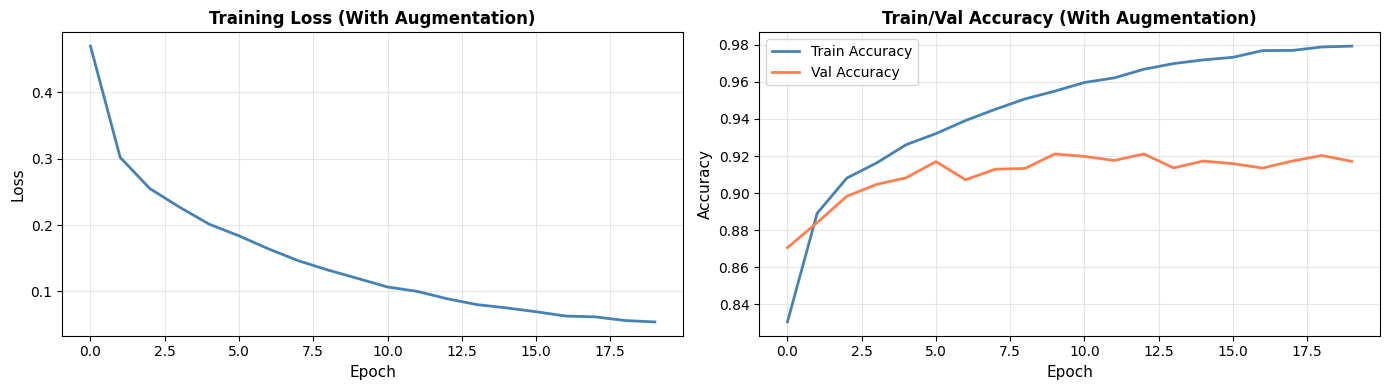

Final Val Accuracy (with augmentation): 0.9171 (91.71%)


In [18]:
# Task 4.2: Plot training loss and accuracies

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Training Loss
axes[0].plot(history_aug.history['loss'], linewidth=2, color='steelblue')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Training Loss (With Augmentation)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[1].plot(history_aug.history['accuracy'], label='Train Accuracy', linewidth=2, color='steelblue')
axes[1].plot(history_aug.history['val_accuracy'], label='Val Accuracy', linewidth=2, color='coral')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Train/Val Accuracy (With Augmentation)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_val_acc = history_aug.history['val_accuracy'][-1]
print(f"Final Val Accuracy (with augmentation): {final_val_acc:.4f} ({100*final_val_acc:.2f}%)")

In [20]:
# Task 4.3: Evaluate on rotated images

def evaluate_on_rotated_images(model, x_test, y_test, angles):
    """
    Evaluate model on test images rotated by different angles.
    """
    accuracies = []

    for angle in angles:
        # Rotate all test images
        # angle in degrees -> convert to number of 90-degree rotations
        k = round(angle / 90) % 4
        x_rotated = np.array([np.rot90(img.squeeze(), k) for img in x_test])
        x_rotated = np.expand_dims(x_rotated, axis=-1)

        # Evaluate
        loss, accuracy = model.evaluate(x_rotated, y_test, verbose=1)
        accuracies.append(accuracy)

    return accuracies

angles = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]

print(f"Evaluating model on {len(angles)} different rotation angles...\n")

acc_with_aug = evaluate_on_rotated_images(model_with_aug, x_test_expanded, y_test, angles)

print("Accuracy by rotation angle (WITH augmentation):")
for angle, acc in zip(angles, acc_with_aug):
    print(f"  {angle:3d}°: {acc:.4f} ({100*acc:.2f}%)")

Evaluating model on 12 different rotation angles...

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9171 - loss: 0.3816
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9171 - loss: 0.3816
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0655 - loss: 16.9400
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0655 - loss: 16.9400
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0655 - loss: 16.9400
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2196 - loss: 8.9100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2196 - loss: 8.9100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2196 - loss: 8.9100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0679 - loss: 18.1347
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0679 - loss: 18.1347
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0679 - loss: 18.1347
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9171 - loss: 0.3816
Accuracy by rotation angle (WITH augmenta

# CIFAR-10 Lab Assignment

Complete the following tasks using CIFAR-10 dataset and a simpler CNN architecture.

## Task 1: Load and Explore CIFAR-10 Dataset

In [ ]:
# Task 1.1: Load CIFAR-10 and print dataset info

# Load the dataset
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = keras.datasets.cifar10.load_data()

# CIFAR-10 class names
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Print dataset information (Task 1.2 requirement: Print shape of training and test data)
print(f"Training data shape: {x_train_cifar.shape}")
print(f"Test data shape:     {x_test_cifar.shape}")
print(f"Number of classes:   10")

In [ ]:
# Task 1.2: Display a 3x3 grid of random images with their class names

plt.figure(figsize=(8, 8))
for i in range(9):
    idx = np.random.randint(0, len(x_train_cifar))
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train_cifar[idx])
    plt.title(cifar_classes[y_train_cifar[idx][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Task 2: Basic Preprocessing

In [ ]:
# Task 2.1: Normalize and Split data

# Normalize pixel values to [0, 1]
x_train_cifar_norm = x_train_cifar.astype('float32') / 255.0
x_test_cifar_norm = x_test_cifar.astype('float32') / 255.0

# Compute and print mean and std of the training set
cifar_mean = np.mean(x_train_cifar_norm, axis=(0, 1, 2))
cifar_std = np.std(x_train_cifar_norm, axis=(0, 1, 2))

print(f"Dataset Mean: {cifar_mean}")
print(f"Dataset Std:  {cifar_std}")

# Further normalize (zero-center)
x_train_cifar_final = (x_train_cifar_norm - cifar_mean) / cifar_std
x_test_cifar_final = (x_test_cifar_norm - cifar_mean) / cifar_std

# Convert labels to categorical (one-hot)
y_train_cifar_cat = keras.utils.to_categorical(y_train_cifar, 10)
y_test_cifar_cat = keras.utils.to_categorical(y_test_cifar, 10)

# Create train/val split (use 50,000 training images total)
print(f"\nPreprocessed Train shape: {x_train_cifar_final.shape}")
print(f"Preprocessed Test shape:  {x_test_cifar_final.shape}")

## Task 3: Build a Simple CNN

In [ ]:
# Task 3.1: Build Sequential model with 2 convolutional blocks

model_cifar = keras.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Classifier head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Print model summary
model_cifar.summary()

## Task 4: Train and Evaluate

In [ ]:
# Task 4.1: Compile and Train model

model_cifar.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 10 epochs with batch_size=64
history_cifar = model_cifar.fit(
    x_train_cifar_final, y_train_cifar_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

In [ ]:
# Task 4.2: Plot training and validation accuracy

plt.figure(figsize=(8, 5))
plt.plot(history_cifar.history['accuracy'], label='Train Accuracy', linewidth=2, color='steelblue')
plt.plot(history_cifar.history['val_accuracy'], label='Val Accuracy', linewidth=2, color='coral')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('CIFAR-10 Training/Validation Accuracy', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Task 4.3: Evaluate on test set

test_loss_cifar, test_acc_cifar = model_cifar.evaluate(x_test_cifar_final, y_test_cifar_cat, verbose=0)
print(f"Test Accuracy: {test_acc_cifar:.4f} ({100*test_acc_cifar:.2f}%)")